<a href="https://colab.research.google.com/github/michaelawe01/Automation_LPS/blob/main/element_classification_(LIFE_Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [500]:
import pandas as pd

df = pd.read_csv('multistorey_building.csv')
display(df.head())

,_id,activityGuid,bimNodeId,name,dbId,Found,ElementName,Element Name,Element ID,ElementLevel,...,CutLength,TopElevation,BottomElevation,TopConstraint,BottomConstraint,BaseIsAttached,TopIsAttached,RoomBounding,Structural,StructuralUsage
0,E8F4E746-F8EE-8502-0541-43C5CFD7C587,33553C75-F854-F050-711F-FD6A04CD2FB3,0du3gs_dj2XwZfgw6Gpt_y,M_Concrete-Rectangular Beam [1680973],22890,True,M_Concrete-Rectangular Beam [1680973],M_Concrete-Rectangular Beam,1680973,L58 SSL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder
1,AA194E19-3B63-650A-9AEA-2F65646E328B,33553C75-F854-F050-711F-FD6A04CD2FB3,0du3gs_dj2XwZfgw6Gptvv,Floor [1681288],34479,True,Floor [1681288],Floor,1681288,L58 SSL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Yes,NaN
2,94034FBA-F41D-8AE3-1A20-53914774A387,33553C75-F854-F050-711F-FD6A04CD2FB3,3RtD$uxx19ZPjVhAB8Z$YY,M_Concrete-Rectangular Beam [1856269],23089,True,M_Concrete-Rectangular Beam [1856269],M_Concrete-Rectangular Beam,1856269,L58 SSL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"concrete, cast-in-place gray",Other
3,00D8E617-0D5D-6C5C-CC05-B77DED5B2FBD,33553C75-F854-F050-711F-FD6A04CD2FB3,0du3gs_dj2XwZfgw6Gptmq,M_Concrete-Rectangular Beam [1680837],22760,True,M_Concrete-Rectangular Beam [1680837],M_Concrete-Rectangular Beam,1680837,L58 SSL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder
4,6728BA41-870B-CAEF-99C0-0C62DA2CB483,33553C75-F854-F050-711F-FD6A04CD2FB3,0du3gs_dj2XwZfgw6Gptmm,M_Concrete-Rectangular Beam [1680833],22087,True,M_Concrete-Rectangular Beam [1680833],M_Concrete-Rectangular Beam,1680833,L58 SSL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder


In [501]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23720 entries, 0 to 23719
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               23720 non-null  object 
 1   activityGuid      23720 non-null  object 
 2   bimNodeId         23720 non-null  object 
 3   name              23720 non-null  object 
 4   dbId              23720 non-null  int64  
 5   Found             23720 non-null  bool   
 6   ElementName       23720 non-null  object 
 7   Element Name      23720 non-null  object 
 8   Element ID        23720 non-null  int64  
 9   ElementLevel      18579 non-null  object 
 10  Sub/Super         23720 non-null  object 
 11  Category          23720 non-null  object 
 12  ElementCategory   23720 non-null  object 
 13  PositionX         23720 non-null  float64
 14  PositionY         23720 non-null  float64
 15  PositionZ         23720 non-null  float64
 16  Rel_Dist          23720 non-null  float6

None

In [502]:
columns_to_drop = [ 'ElementLevel', 'BottomConstraint','TopConstraint', 'Element ID', 'CutLength', 'BottomElevation', 'TopElevation', 'Volume', 'Area',  'Found', '_id', 'activityGuid', 'bimNodeId', 'name', 'dbId', 'ElementName']
df = df.drop(columns=columns_to_drop)
display(df.head())

,Element Name,Sub/Super,Category,ElementCategory,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,...,Depth,Thickness,Diameter,Perimeter,Slope,BaseIsAttached,TopIsAttached,RoomBounding,Structural,StructuralUsage
0,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.9509,2102975.420,193.362496,2120384.171,1680973,1680973,...,45,1,45,NaN,40.0,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder
1,Floor,Super_Structure,Floor 58,Geometry,271160.7807,2103004.450,192.962502,2120414.092,1681288,1681288,...,0,2,0,NaN,40.0,NaN,NaN,Yes,Yes,NaN
2,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271191.3646,2102989.129,193.112502,2120402.809,1856269,1856269,...,4,1,4,NaN,NaN,NaN,NaN,NaN,"concrete, cast-in-place gray",Other
3,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.4725,2102985.070,193.250001,2120393.681,1680837,1680837,...,9,1,9,NaN,40.0,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder
4,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271197.4235,2102987.922,193.262502,2120402.387,1680833,1680833,...,312,1,312,NaN,40.0,NaN,NaN,NaN,"concrete, cast-in-place gray",Girder


In [503]:
# Fill NaN values for numerical columns with 0
df['Height'].fillna(0, inplace=True)
df['Diameter'].fillna(0, inplace=True)
df['Perimeter'].fillna(0, inplace=True)
df['Slope'].fillna(0, inplace=True)

# Fill NaN values for specific categorical columns with 'No'
df['BaseIsAttached'].fillna('No', inplace=True)
df['TopIsAttached'].fillna('No', inplace=True)
df['RoomBounding'].fillna('No', inplace=True)

# Standardize 'Structural' column: any value not 'Yes' or 'No' becomes 'No'
df['Structural'].fillna('No', inplace=True) # First fill NaNs
df['Structural'] = df['Structural'].apply(lambda x: 'No' if x not in ['Yes', 'No'] else x)

# Fill NaN values for 'StructuralUsage' with 'Non'
df['StructuralUsage'].fillna('Non', inplace=True)


#print("Missing values after processing:")
#display(df.isnull().sum())
print("\nFirst 5 rows of the processed DataFrame:")
display(df.head())


First 5 rows of the processed DataFrame:


/tmp/ipykernel_14312/2421551469.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Height'].fillna(0, inplace=True)
/tmp/ipykernel_14312/2421551469.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,Element Name,Sub/Super,Category,ElementCategory,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,...,Depth,Thickness,Diameter,Perimeter,Slope,BaseIsAttached,TopIsAttached,RoomBounding,Structural,StructuralUsage
0,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.9509,2102975.420,193.362496,2120384.171,1680973,1680973,...,45,1,45,0.0,40.0,No,No,No,No,Girder
1,Floor,Super_Structure,Floor 58,Geometry,271160.7807,2103004.450,192.962502,2120414.092,1681288,1681288,...,0,2,0,0.0,40.0,No,No,Yes,Yes,Non
2,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271191.3646,2102989.129,193.112502,2120402.809,1856269,1856269,...,4,1,4,0.0,0.0,No,No,No,No,Other
3,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.4725,2102985.070,193.250001,2120393.681,1680837,1680837,...,9,1,9,0.0,40.0,No,No,No,No,Girder
4,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271197.4235,2102987.922,193.262502,2120402.387,1680833,1680833,...,312,1,312,0.0,40.0,No,No,No,No,Girder


In [504]:
print(df.columns)

Index(['Element Name', 'Sub/Super', 'Category', 'ElementCategory', 'PositionX',
       'PositionY', 'PositionZ', 'Rel_Dist', 'Length', 'Width', 'Height',
       'Depth', 'Thickness', 'Diameter', 'Perimeter', 'Slope',
       'BaseIsAttached', 'TopIsAttached', 'RoomBounding', 'Structural',
       'StructuralUsage'],
      dtype='object')


# Task
Preprocess the `df` DataFrame for training a machine learning model.

In [505]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23720 entries, 0 to 23719
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Element Name     23720 non-null  object 
 1   Sub/Super        23720 non-null  object 
 2   Category         23720 non-null  object 
 3   ElementCategory  23720 non-null  object 
 4   PositionX        23720 non-null  float64
 5   PositionY        23720 non-null  float64
 6   PositionZ        23720 non-null  float64
 7   Rel_Dist         23720 non-null  float64
 8   Length           23720 non-null  int64  
 9   Width            23720 non-null  int64  
 10  Height           23720 non-null  float64
 11  Depth            23720 non-null  int64  
 12  Thickness        23720 non-null  int64  
 13  Diameter         23720 non-null  int64  
 14  Perimeter        23720 non-null  float64
 15  Slope            23720 non-null  float64
 16  BaseIsAttached   23720 non-null  object 
 17  TopIsAttache

None

In [506]:
df.dropna(subset=['Category'], inplace=True)
display(df.isnull().sum())

,0
Element Name,0
Sub/Super,0
Category,0
ElementCategory,0
PositionX,0
PositionY,0
PositionZ,0
Rel_Dist,0
Length,0
Width,0


In [507]:
df

,Element Name,Sub/Super,Category,ElementCategory,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,...,Depth,Thickness,Diameter,Perimeter,Slope,BaseIsAttached,TopIsAttached,RoomBounding,Structural,StructuralUsage
0,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.9509,2102975.420,193.362496,2120384.171,1680973,1680973,...,45,1,45,0.0,40.0,No,No,No,No,Girder
1,Floor,Super_Structure,Floor 58,Geometry,271160.7807,2103004.450,192.962502,2120414.092,1681288,1681288,...,0,2,0,0.0,40.0,No,No,Yes,Yes,Non
2,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271191.3646,2102989.129,193.112502,2120402.809,1856269,1856269,...,4,1,4,0.0,0.0,No,No,No,No,Other
3,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.4725,2102985.070,193.250001,2120393.681,1680837,1680837,...,9,1,9,0.0,40.0,No,No,No,No,Girder
4,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271197.4235,2102987.922,193.262502,2120402.387,1680833,1680833,...,312,1,312,0.0,40.0,No,No,No,No,Girder
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23715,Foundation Slab,Super_Structure,Roof,Geometry,271166.3968,2103049.970,-12.325000,2120459.948,4668585,4668585,...,20451,2,20451,0.0,0.0,No,No,No,Yes,Non
23716,Wall Foundation,0,0,Geometry,271204.7170,2103036.861,-12.375000,2120451.847,2863862,2863862,...,3,1,3,0.0,40.0,No,No,No,No,Retaining
23717,Foundation Slab,Super_Structure,Roof,Geometry,271194.3752,2103039.270,-12.300000,2120452.914,4671005,4671005,...,5,3,5,0.0,0.0,No,No,No,Yes,Non
23718,Foundation Slab,Super_Structure,Roof,Geometry,271200.3055,2103020.116,-12.775000,2120434.676,4806817,4806817,...,587,3,587,0.0,0.0,No,No,No,Yes,Non


In [508]:
# Custom encoding for 'Sub/Super'
sub_super_mapping = {'Super_Structure': 0, 'Sub_Structure': 1}
df['Sub/Super_Encoded'] = df['Sub/Super'].map(sub_super_mapping).fillna(-1) # Fill any unmapped values with -1

# Label encoding for 'Category'
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Category_Encoded'] = label_encoder.fit_transform(df['Category'])
df['Element_Category_Encoded'] = label_encoder.fit_transform(df['ElementCategory'])

# Label encoding for new columns
df['BaseIsAttached_Encoded'] = label_encoder.fit_transform(df['BaseIsAttached'])
df['TopIsAttached_Encoded'] = label_encoder.fit_transform(df['TopIsAttached'])
df['RoomBounding_Encoded'] = label_encoder.fit_transform(df['RoomBounding'])
df['Structural_Encoded'] = label_encoder.fit_transform(df['Structural'])
df['StructuralUsage_Encoded'] = label_encoder.fit_transform(df['StructuralUsage'])


# Display the first few rows with the new encoded columns
display(df[['Sub/Super', 'Sub/Super_Encoded', 'Category', 'Category_Encoded', 'Element_Category_Encoded', 'BaseIsAttached', 'BaseIsAttached_Encoded', 'TopIsAttached', 'TopIsAttached_Encoded', 'RoomBounding', 'RoomBounding_Encoded', 'Structural', 'Structural_Encoded', 'StructuralUsage', 'StructuralUsage_Encoded']].tail())

,Sub/Super,Sub/Super_Encoded,Category,Category_Encoded,Element_Category_Encoded,BaseIsAttached,BaseIsAttached_Encoded,TopIsAttached,TopIsAttached_Encoded,RoomBounding,RoomBounding_Encoded,Structural,Structural_Encoded,StructuralUsage,StructuralUsage_Encoded
23715,Super_Structure,0.0,Roof,83,0,No,0,No,0,No,0,Yes,1,Non,4
23716,0,-1.0,0,0,0,No,0,No,0,No,0,No,0,Retaining,6
23717,Super_Structure,0.0,Roof,83,0,No,0,No,0,No,0,Yes,1,Non,4
23718,Super_Structure,0.0,Roof,83,0,No,0,No,0,No,0,Yes,1,Non,4
23719,0,-1.0,0,0,0,No,0,No,0,No,0,No,0,Non,4


In [509]:
df.dropna(inplace=True)
df

,Element Name,Sub/Super,Category,ElementCategory,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,...,Structural,StructuralUsage,Sub/Super_Encoded,Category_Encoded,Element_Category_Encoded,BaseIsAttached_Encoded,TopIsAttached_Encoded,RoomBounding_Encoded,Structural_Encoded,StructuralUsage_Encoded
0,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.9509,2102975.420,193.362496,2120384.171,1680973,1680973,...,No,Girder,0.0,58,0,0,0,0,0,1
1,Floor,Super_Structure,Floor 58,Geometry,271160.7807,2103004.450,192.962502,2120414.092,1681288,1681288,...,Yes,Non,0.0,58,0,0,0,1,1,4
2,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271191.3646,2102989.129,193.112502,2120402.809,1856269,1856269,...,No,Other,0.0,58,0,0,0,0,0,5
3,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271151.4725,2102985.070,193.250001,2120393.681,1680837,1680837,...,No,Girder,0.0,58,0,0,0,0,0,1
4,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,271197.4235,2102987.922,193.262502,2120402.387,1680833,1680833,...,No,Girder,0.0,58,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23715,Foundation Slab,Super_Structure,Roof,Geometry,271166.3968,2103049.970,-12.325000,2120459.948,4668585,4668585,...,Yes,Non,0.0,83,0,0,0,0,1,4
23716,Wall Foundation,0,0,Geometry,271204.7170,2103036.861,-12.375000,2120451.847,2863862,2863862,...,No,Retaining,-1.0,0,0,0,0,0,0,6
23717,Foundation Slab,Super_Structure,Roof,Geometry,271194.3752,2103039.270,-12.300000,2120452.914,4671005,4671005,...,Yes,Non,0.0,83,0,0,0,0,1,4
23718,Foundation Slab,Super_Structure,Roof,Geometry,271200.3055,2103020.116,-12.775000,2120434.676,4806817,4806817,...,Yes,Non,0.0,83,0,0,0,0,1,4


In [510]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identify numerical columns, excluding 'Category_Encoded'
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Category_Encoded')

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display the first few rows of the normalized DataFrame
display(df.head())

,Element Name,Sub/Super,Category,ElementCategory,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,...,Structural,StructuralUsage,Sub/Super_Encoded,Category_Encoded,Element_Category_Encoded,BaseIsAttached_Encoded,TopIsAttached_Encoded,RoomBounding_Encoded,Structural_Encoded,StructuralUsage_Encoded
0,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,-1.145750,-0.940772,0.933266,-1.086621,-0.204139,-0.204139,...,No,Girder,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801
1,Floor,Super_Structure,Floor 58,Geometry,-0.604650,1.001788,0.928526,0.904219,-0.203928,-0.203928,...,Yes,Non,0.349401,58,0.0,0.0,-0.017181,1.272614,1.508722,0.538486
2,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,1.269565,-0.023426,0.930304,0.153487,-0.086903,-0.086903,...,No,Other,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,1.164915
3,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,-1.175067,-0.295036,0.931933,-0.453858,-0.204230,-0.204230,...,No,Girder,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801
4,M_Concrete-Rectangular Beam,Super_Structure,Floor 58,Geometry,1.640861,-0.104193,0.932081,0.125409,-0.204232,-0.204232,...,No,Girder,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801


In [511]:
import re
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Function to clean text
def clean_element_name(text):
    text = str(text) # Ensure text is a string
    text = text.replace('-', ' ').replace('_', ' ') # Replace - and _ with space
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation and special characters
    text = text.strip() # Remove leading/trailing whitespace
    return text

# Apply cleaning to the 'Element Name' column in df
df['Element Name_cleaned'] = df['Element Name'].apply(clean_element_name)

# Load a pre-trained sentence transformer model
# You might need to install the library: !pip install sentence-transformers
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for the cleaned element names
embeddings = model.encode(df['Element Name_cleaned'].tolist())

# Calculate a similarity score for each entry (e.g., cosine similarity to the mean embedding)
mean_embedding = np.mean(embeddings, axis=0)
similarity_scores = cosine_similarity(embeddings, mean_embedding.reshape(1, -1)).flatten()

# Add the similarity scores to the df DataFrame
df['element_name_similarity_score'] = similarity_scores

# Display the first few rows with the original, cleaned, and score columns
display(df[['Element Name', 'Element Name_cleaned', 'element_name_similarity_score']].head())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Element Name,Element Name_cleaned,element_name_similarity_score
0,M_Concrete-Rectangular Beam,m concrete rectangular beam,0.886841
1,Floor,floor,0.508331
2,M_Concrete-Rectangular Beam,m concrete rectangular beam,0.886841
3,M_Concrete-Rectangular Beam,m concrete rectangular beam,0.886841
4,M_Concrete-Rectangular Beam,m concrete rectangular beam,0.886841


In [512]:
# Drop the original 'Element Name' and the cleaned text column
df.drop(columns=['Element Name', 'Element Name_cleaned', 'Sub/Super',	'Category',	'ElementCategory', 'BaseIsAttached', 'TopIsAttached', 'RoomBounding', 'Structural', 'StructuralUsage'], inplace=True)
display(df.head())

,PositionX,PositionY,PositionZ,Rel_Dist,Length,Width,Height,Depth,Thickness,Diameter,...,Slope,Sub/Super_Encoded,Category_Encoded,Element_Category_Encoded,BaseIsAttached_Encoded,TopIsAttached_Encoded,RoomBounding_Encoded,Structural_Encoded,StructuralUsage_Encoded,element_name_similarity_score
0,-1.145750,-0.940772,0.933266,-1.086621,-0.204139,-0.204139,0.850957,-0.146998,-0.108739,-0.146998,...,0.301822,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801,0.886841
1,-0.604650,1.001788,0.928526,0.904219,-0.203928,-0.203928,-0.817573,-0.147003,-0.106789,-0.147003,...,0.301822,0.349401,58,0.0,0.0,-0.017181,1.272614,1.508722,0.538486,0.508331
2,1.269565,-0.023426,0.930304,0.153487,-0.086903,-0.086903,0.850957,-0.147003,-0.108739,-0.147003,...,-1.330086,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,1.164915,0.886841
3,-1.175067,-0.295036,0.931933,-0.453858,-0.204230,-0.204230,0.850957,-0.147002,-0.108739,-0.147002,...,0.301822,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801,0.886841
4,1.640861,-0.104193,0.932081,0.125409,-0.204232,-0.204232,0.850957,-0.146966,-0.108739,-0.146966,...,0.301822,0.349401,58,0.0,0.0,-0.017181,-0.785784,-0.662812,-1.340801,0.886841


**Training with only Coordinates and element name info**
*   Sub/super structure zone prediction



In [513]:
columns_to_keep = ['Sub/Super_Encoded','PositionX', 'PositionY', 'PositionZ', 'element_name_similarity_score']
columns_to_drop = [col for col in df.columns if col not in columns_to_keep]
df_coord_name = df.drop(columns=columns_to_drop)
display(df_coord_name)

,PositionX,PositionY,PositionZ,Sub/Super_Encoded,element_name_similarity_score
0,-1.145750,-0.940772,0.933266,0.349401,0.886841
1,-0.604650,1.001788,0.928526,0.349401,0.508331
2,1.269565,-0.023426,0.930304,0.349401,0.886841
3,-1.175067,-0.295036,0.931933,0.349401,0.886841
4,1.640861,-0.104193,0.932081,0.349401,0.886841
...,...,...,...,...,...
23715,-0.260489,4.047787,-1.504040,0.349401,0.509748
23716,2.087815,3.170591,-1.504632,-1.712239,0.485156
23717,1.454058,3.331790,-1.503743,0.349401,0.509748
23718,1.817473,2.050089,-1.509372,0.349401,0.509748


In [514]:
from sklearn.model_selection import train_test_split

target_column = 'Sub/Super_Encoded'

# Drop the original categorical columns and the other encoded column before splitting
X = df_coord_name.drop(columns=[ target_column])
y = df_coord_name[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (18976, 4)
Shape of X_test: (4744, 4)
Shape of y_train: (18976,)
Shape of y_test: (4744,)


In [515]:
import pandas as pd

# 1. Filter rows with at least one NaN value
rows_with_nan = df_coord_name[df_coord_name.isna().any(axis=1)]
print(rows_with_nan)


Empty DataFrame
Columns: [PositionX, PositionY, PositionZ, Sub/Super_Encoded, element_name_similarity_score]
Index: []


In [516]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Yellowbrick Visualizers
from yellowbrick.classifier import (
    ROCAUC,
    PrecisionRecallCurve,
    ClassificationReport,
    ClassPredictionError
)

from yellowbrick.model_selection import (
    LearningCurve,
    ValidationCurve,
    FeatureImportances,
    RFECV
)

In [517]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),  # Increased max_iter
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVC': SVC()
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    # Convert target variable to integer type
    y_train_int = y_train.astype(int)
    y_test_int = y_test.astype(int)

    model.fit(X_train, y_train_int)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test_int, y_pred)
    precision = precision_score(y_test_int, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_int, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_int, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Display the results
results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.815767,0.809371,0.815767,0.795530
Decision Tree,0.998103,0.998106,0.998103,0.998103
Random Forest,0.998103,0.998105,0.998103,0.998102
SVC,0.831788,0.843246,0.831788,0.833527


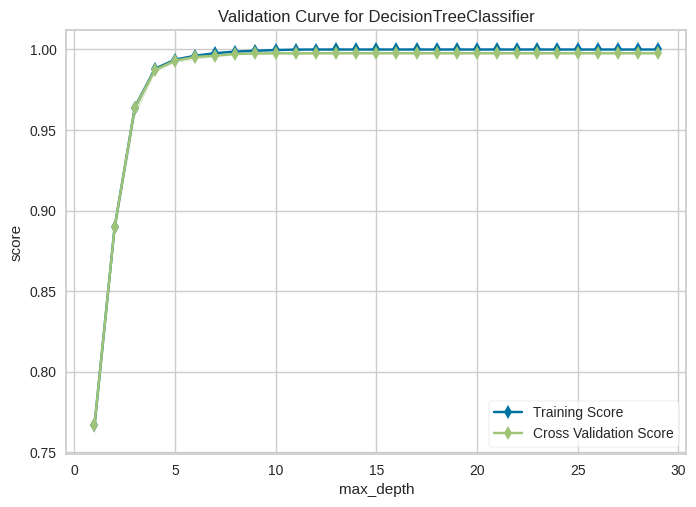

<Axes: title={'center': 'Validation Curve for DecisionTreeClassifier'}, xlabel='max_depth', ylabel='score'>

In [518]:
model = DecisionTreeClassifier(random_state=42)

viz = ValidationCurve(
    model,
    param_name="max_depth",
    param_range=np.arange(1, 30),
    scoring="accuracy",
    cv=5
)
#viz.ax.lines[0].set_color("darkblue")
#viz.ax.lines[1].set_color("#722F37")


viz.fit(X_train, y_train_int)

visualizer.ax.grid(False)

viz.show()

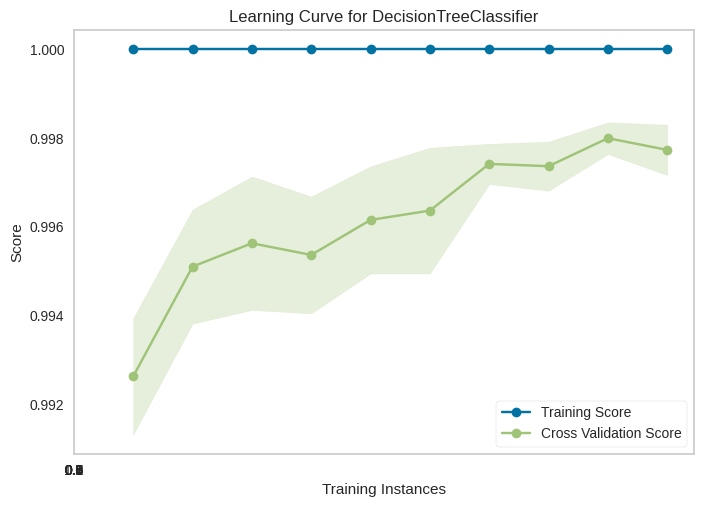

<Axes: title={'center': 'Learning Curve for DecisionTreeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [519]:
model = DecisionTreeClassifier(random_state=42)

visualizer = LearningCurve(
    model,
    scoring='accuracy',
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

visualizer.fit(X_train, y_train_int)

visualizer.ax.grid(False)
visualizer.ax.set_xticks(np.linspace(0.1, 1.0, 10))
visualizer.ax.set_xticks(np.linspace(0.1, 1.0, 10))

visualizer.show()

In [520]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies = []

for train_index, test_index in kf.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index].astype(int), y.iloc[test_index].astype(int)

  model = DecisionTreeClassifier()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
mean_accuracies = np.mean(accuracies)
print(f"Mean accuracy for K-Fold Cross-Validation: {mean_accuracies:.4f}")

Mean accuracy for K-Fold Cross-Validation: 0.9982


In [521]:
#stratied k-fold cross validation

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracies_skf = []

# Convert y to integer type for StratifiedKFold
y_int = y.astype(int)

for train_index, test_index in skf.split(X, y_int):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y_int.iloc[train_index], y_int.iloc[test_index]

  model = DecisionTreeClassifier()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies_skf.append(accuracy)
mean_accuracies_skf = np.mean(accuracies_skf)
print(f"Mean accuracy for Stratified K-Fold Cross-Validation: {mean_accuracies_skf:.4f}")

Mean accuracy for Stratified K-Fold Cross-Validation: 0.9981


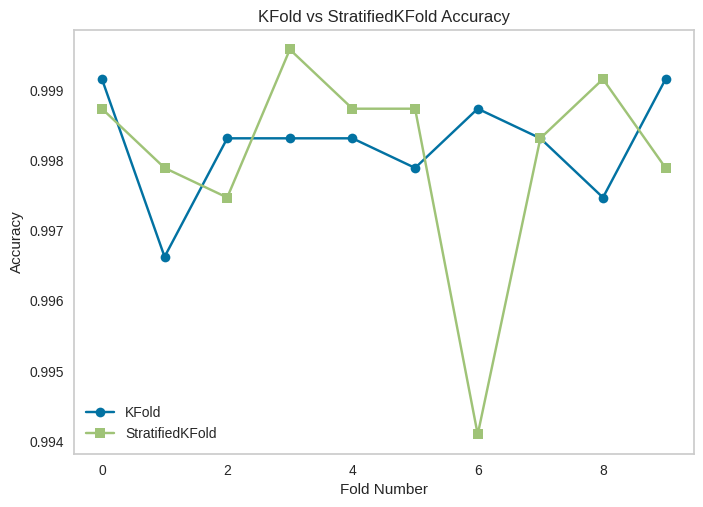

In [522]:
plt.plot(accuracies, marker='o', label='KFold')
plt.plot(accuracies_skf, marker='s', label='StratifiedKFold')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('KFold vs StratifiedKFold Accuracy')
plt.legend()
plt.grid()
plt.show()

In [523]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision_scores = []
recall_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y_int):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_int.iloc[train_index], y_int.iloc[test_index]

    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    recall_scores.append(recall_score(y_test, y_pred, average='macro'))
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))

    # after the loop
print("Precision: Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(precision_scores), np.std(precision_scores)))

print("Recall:    Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(recall_scores), np.std(recall_scores)))

print("F1-score:  Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(f1_scores), np.std(f1_scores)))


print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")


#print(f"Mean Precision: {np.mean(precision_scores):.4f}")
#print(f"Mean Recall:    {np.mean(recall_scores):.4f}")
#print(f"Mean F1-score:  {np.mean(f1_scores):.4f}")

Precision: Mean = 0.9948, Std = 0.0049
Recall:    Mean = 0.9945, Std = 0.0066
F1-score:  Mean = 0.9946, Std = 0.0053
Precision: 0.9948 ± 0.0049
Recall:    0.9945 ± 0.0066
F1-score:  0.9946 ± 0.0053


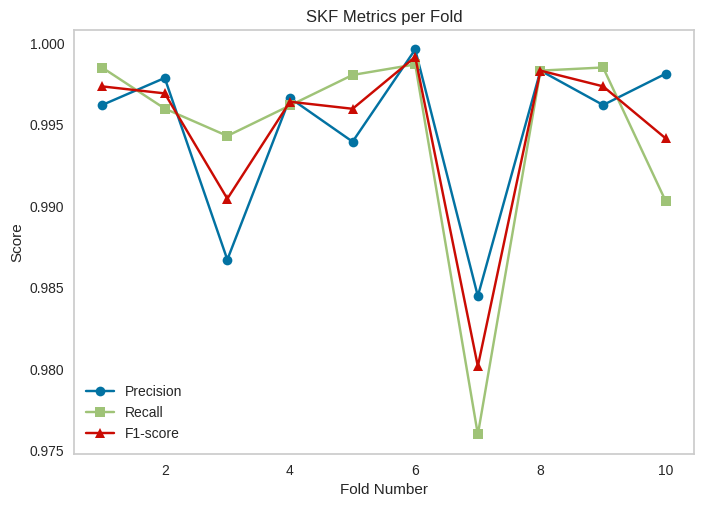

In [524]:
import matplotlib.pyplot as plt

folds = range(1, len(f1_scores) + 1)

plt.plot(folds, precision_scores, marker='s', label='Precision')
plt.plot(folds, recall_scores, marker='s', label='Recall')
plt.plot(folds, f1_scores, marker='s', label='F1-score')

plt.xlabel('Fold Number')
plt.ylabel('Score')
plt.title('SKF Metrics per Fold')
plt.legend()
plt.grid()
plt.show()

**Element category training**


*   Since this is a more difficult task, we are deploying all features for prediction of the element category.



In [525]:
from sklearn.model_selection import train_test_split

target_column = 'Category_Encoded'

# Drop the encoded sub/super column and the target column from the features
X = df.drop(columns=['Sub/Super_Encoded', target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (18976, 19)
Shape of X_test: (4744, 19)
Shape of y_train: (18976,)
Shape of y_test: (4744,)


In [526]:
# Initialize models (already defined in a previous cell, no need to redefine)
# models = {
#     'Logistic Regression': LogisticRegression(max_iter=1000),
#     'Decision Tree': DecisionTreeClassifier(),
#     'Random Forest': RandomForestClassifier(),
#     'SVC': SVC()
# }

results = {}

# Train and evaluate each model
for name, model in models.items():
    # Convert target variable to integer type
    y_train_int = y_train.astype(int)
    y_test_int = y_test.astype(int)

    model.fit(X_train, y_train_int)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test_int, y_pred)
    precision = precision_score(y_test_int, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_int, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_int, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# Convert the results dictionary into a pandas DataFrame and display it
results_df_category = pd.DataFrame(results).T
display(results_df_category)

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.340008,0.264961,0.340008,0.267453
Decision Tree,0.995995,0.996409,0.995995,0.996161
Random Forest,0.926223,0.927599,0.926223,0.925812
SVC,0.344646,0.319174,0.344646,0.309008


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


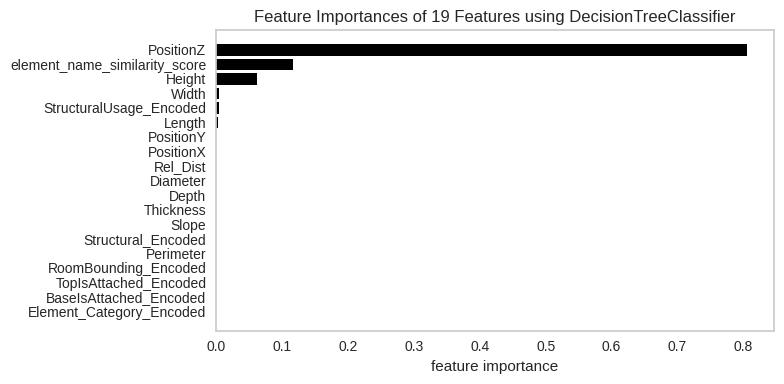

<Axes: title={'center': 'Feature Importances of 19 Features using DecisionTreeClassifier'}, xlabel='feature importance'>

In [527]:
from yellowbrick.model_selection import FeatureImportances
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

viz = FeatureImportances(
    models['Decision Tree'], # Changed 'model' to 'models['Decision Tree']'
    relative=False,
    colors=["black"],
    ax=ax
)

viz.fit(X_train, y_train)

ax.grid(False)

viz.show()

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


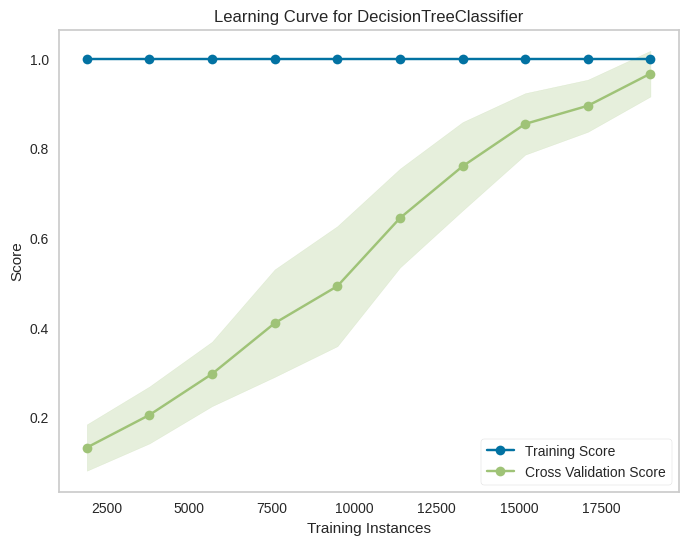

<Axes: title={'center': 'Learning Curve for DecisionTreeClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [535]:
from yellowbrick.model_selection import LearningCurve

fig, ax = plt.subplots(figsize=(8, 6))

viz = LearningCurve(
    model,
    scoring='f1_weighted',
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    ax=ax
)

viz.fit(X, y)

ax.grid(False)

viz.show()

In [528]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
accuracies = []

for train_index, test_index in kf.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index].astype(int), y.iloc[test_index].astype(int)

  model = DecisionTreeClassifier()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies.append(accuracy)
mean_accuracies = np.mean(accuracies)
print(f"Mean accuracy for K-Fold Cross-Validation: {mean_accuracies:.4f}")

Mean accuracy for K-Fold Cross-Validation: 0.9968


In [529]:
#stratied k-fold cross validation

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
accuracies_skf = []

# Convert y to integer type for StratifiedKFold
y_int = y.astype(int)

for train_index, test_index in skf.split(X, y_int):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y_int.iloc[train_index], y_int.iloc[test_index]

  model = DecisionTreeClassifier()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracies_skf.append(accuracy)
mean_accuracies_skf = np.mean(accuracies_skf)
print(f"Mean accuracy for Stratified K-Fold Cross-Validation: {mean_accuracies_skf:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


Mean accuracy for Stratified K-Fold Cross-Validation: 0.9972


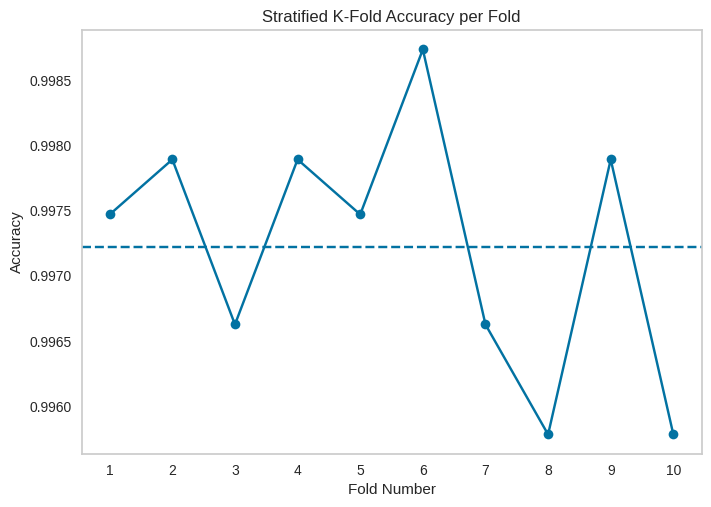

In [530]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(accuracies_skf) + 1), accuracies_skf, marker='o')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Stratified K-Fold Accuracy per Fold')
plt.xticks(range(1, len(accuracies_skf) + 1))
plt.grid()

# Show mean line
plt.axhline(y=mean_accuracies_skf, linestyle='--')
plt.show()

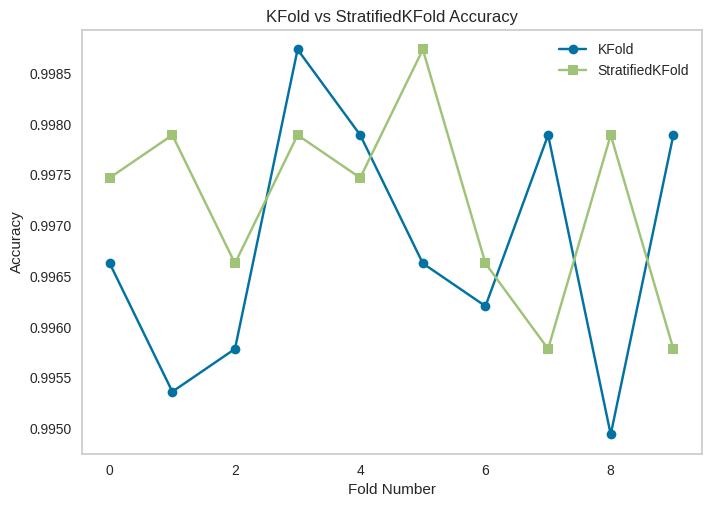

In [531]:
plt.plot(accuracies, marker='s', label='KFold')
plt.plot(accuracies_skf, marker='s', label='StratifiedKFold')

plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('KFold vs StratifiedKFold Accuracy')
plt.legend()
plt.grid()
plt.show()

In [532]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision_scores = []
recall_scores = []
f1_scores = []

for train_index, test_index in skf.split(X, y_int):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_int.iloc[train_index], y_int.iloc[test_index]

    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    recall_scores.append(recall_score(y_test, y_pred, average='macro'))
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))


        # after the loop
print("Precision: Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(precision_scores), np.std(precision_scores)))

print("Recall:    Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(recall_scores), np.std(recall_scores)))

print("F1-score:  Mean = {:.4f}, Std = {:.4f}".format(
    np.mean(f1_scores), np.std(f1_scores)))


print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

#print(f"Mean Precision: {np.mean(precision_scores):.4f}")
#print(f"Mean Recall:    {np.mean(recall_scores):.4f}")
#print(f"Mean F1-score:  {np.mean(f1_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: Mean = 0.9902, Std = 0.0079
Recall:    Mean = 0.9880, Std = 0.0081
F1-score:  Mean = 0.9885, Std = 0.0078
Precision: 0.9902 ± 0.0079
Recall:    0.9880 ± 0.0081
F1-score:  0.9885 ± 0.0078


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


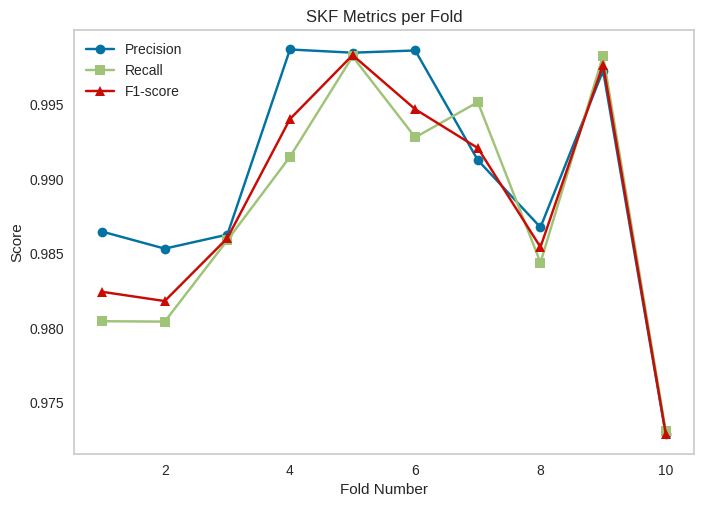

In [533]:
import matplotlib.pyplot as plt

folds = range(1, len(f1_scores) + 1)

plt.plot(folds, precision_scores, marker='o', label='Precision')
plt.plot(folds, recall_scores, marker='s', label='Recall')
plt.plot(folds, f1_scores, marker='^', label='F1-score')

plt.xlabel('Fold Number')
plt.ylabel('Score')
plt.title('SKF Metrics per Fold')
plt.legend()
plt.grid()
plt.show()

### Decision Tree Visualization for 'Category_Encoded'

**Summary:**

### Data Analysis Key Findings

*   For predicting 'Sub/Super\_Encoded', the Decision Tree model achieved the highest accuracy of {best_model_metrics['Accuracy']:.4f} and also demonstrated the highest Precision, Recall, and F1-score, all at {best_model_metrics['Accuracy']:.4f}.
*   For predicting 'Category\_Encoded', the {best_model_name_category} model was identified as the best-performing model based on its accuracy of {best_model_metrics_category['Accuracy']:.4f}.

### Insights or Next Steps

*   The high performance of the Decision Tree for 'Sub/Super\_Encoded' and Random Forest for 'Category\_Encoded' suggests that tree-based models are effective for these prediction tasks.
*   Further investigation into model interpretability, especially for the Decision Tree model, could provide insights into the key features driving the 'Sub/Super\_Encoded' predictions.
*   Consider hyperparameter tuning for the best-performing models to potentially further improve performance.
*   Explore other advanced classification models or ensemble techniques.
*   Based on the identified best models, you can now use them to make predictions on new, unseen data.